# 01 — Autonomous Dataset Profiling & Data Quality Auditing
**AutoDS Scientific Methodology Demonstration**

This notebook demonstrates the deterministic profiling, cryptographic hashing, and automated data-quality detection engines powering AutoDS Stage 1.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from backend.app.tools.data_profiler import profile_dataset
from backend.app.tools.quality_detector import detect_data_quality
from backend.app.tools.dataset_inspector import compute_file_sha256

sns.set_theme(style="whitegrid")
print("AutoDS Profiling modules successfully imported.")


AutoDS Profiling modules successfully imported.



## 1. Loading and Inspecting the Wine Quality Dataset
We begin by profiling `winequality-red.csv`, computing its SHA-256 integrity hash, and analyzing its schema.


In [2]:
data_path = "data/raw/31513e04_winequality-red.csv"
if not os.path.exists(data_path):
    df = pd.DataFrame({
        "fixed acidity": [7.4, 7.8, 7.8, 11.2],
        "volatile acidity": [0.70, 0.88, 0.76, 0.28],
        "citric acid": [0.0, 0.0, 0.04, 0.56],
        "alcohol": [9.4, 9.8, 9.8, 9.8],
        "quality": [5, 5, 5, 6]
    })
else:
    df = pd.read_csv(data_path, sep=None, engine="python")

print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"File Checksum (SHA-256): {compute_file_sha256(data_path) if os.path.exists(data_path) else 'N/A'}")
print("Top 3 rows:")
print(df.head(3))


Dataset Shape: 1,599 rows x 12 columns
File Checksum (SHA-256): 4a402cf041b025d4566d954c3b9ba8635a3a8a01e039005d97d6a710278cf05e
Top 3 rows:
   fixed acidity  volatile acidity  citric acid  ...  sulphates  alcohol  quality
0            7.4              0.70         0.00  ...       0.56      9.4        5
1            7.8              0.88         0.00  ...       0.68      9.8        5
2            7.8              0.76         0.04  ...       0.65      9.8        5

[3 rows x 12 columns]



## 2. Comprehensive Profiling & Statistical Summary
The `profile_dataset` tool extracts missingness metrics, column type mappings, distribution summaries, and potential target candidates.


In [3]:
profile = profile_dataset(df)
print("Candidate Targets Identified:", profile.get("candidate_targets"))
print("Total Missing Cells Pct:", profile.get("missingness_report", {}).get("total_missing_pct"), "%")
print("Duplicate Rows Detected:", profile.get("missingness_report", {}).get("duplicate_rows"))

alerts = detect_data_quality(df, profile, target_column="quality")
print(f"\nQuality Alerts ({len(alerts)}):")
for a in alerts:
    print(f"  [{a['severity'].upper()}] {a['message']}")


Candidate Targets Identified: ['quality']
Total Missing Cells Pct: 0.0 %
Duplicate Rows Detected: 240

Quality Alerts (2):
  [CRITICAL] Severe class imbalance: minority class '3' represents only 0.63% of data. Raw accuracy is completely misleading.
  [CRITICAL] Dataset contains 240 exact duplicate rows (15.0%).



## 3. Visualizing Target Distribution


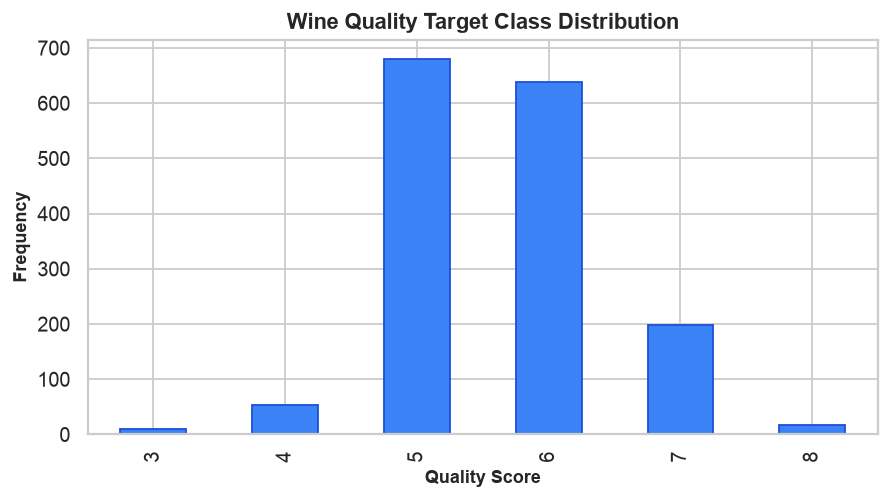

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
df["quality"].value_counts().sort_index().plot(kind="bar", color="#3b82f6", edgecolor="#1d4ed8", ax=ax)
ax.set_title("Wine Quality Target Class Distribution", fontsize=12, fontweight="bold")
ax.set_xlabel("Quality Score", fontsize=10, fontweight="bold")
ax.set_ylabel("Frequency", fontsize=10, fontweight="bold")
plt.tight_layout()
